## Colab setup
Run the cell below first. It uploads `X_train.npy` and `labels_train.npy` (the FD001 training arrays) and stages them where the rest of the notebook expects to find them.


In [13]:
import sys
from pathlib import Path
import shutil

IN_COLAB = "google.colab" in sys.modules

DATA_DIR = Path("data/processed/FD001")
DATA_DIR.mkdir(parents=True, exist_ok=True)

if IN_COLAB:
    from google.colab import files

    print("Select X_train.npy and labels_train.npy to upload...")
    uploaded = files.upload()

    for fname in uploaded.keys():
        shutil.move(fname, DATA_DIR / fname)

    print(f"Staged in {DATA_DIR.resolve()}:")
    for p in sorted(DATA_DIR.iterdir()):
        print(f"  - {p.name}")
else:
    print("Not running in Colab — assuming the .npy files are already in", DATA_DIR.resolve())


Select X_train.npy and labels_train.npy to upload...


Saving X_train.npy to X_train.npy
Saving labels_train.npy to labels_train.npy
Staged in /content/data/processed/FD001:
  - X_train.npy
  - checkpoints_cgan
  - labels_train.npy


In [14]:
SEED = 42
import numpy as np
import torch
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
from pathlib import Path
Path("reports/figures").mkdir(parents=True, exist_ok=True)
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR   = Path("data/processed/FD001")
MODELS_DIR = Path("data/processed/FD001/checkpoints_cgan")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X      = np.load(DATA_DIR / "X_train.npy")
labels = np.load(DATA_DIR / "labels_train.npy")

INPUT_DIM   = X.shape[2]
SEQ_LEN     = X.shape[1]
LATENT_DIM  = 64
HIDDEN_DIM  = 128
NUM_CLASSES = 4
EMBED_DIM   = 16
BATCH_SIZE  = 64

cfg = {
    "seq_len"    : SEQ_LEN,
    "input_dim"  : INPUT_DIM,
    "hidden_dim" : HIDDEN_DIM,
    "latent_dim" : LATENT_DIM,
    "num_classes": NUM_CLASSES,
    "embed_dim"  : EMBED_DIM,
    "model_type" : "cgan",
}
with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(cfg, f, indent=2)

print(f"X      : {X.shape}")
print(f"Device : {DEVICE}")
print(f"Config : {cfg}")

X      : (17731, 30, 16)
Device : cuda
Config : {'seq_len': 30, 'input_dim': 16, 'hidden_dim': 128, 'latent_dim': 64, 'num_classes': 4, 'embed_dim': 16, 'model_type': 'cgan'}


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

def correlation_penalty(x_real: torch.Tensor, x_fake: torch.Tensor) -> torch.Tensor:
    B = x_real.size(0)
    real_flat = x_real.reshape(B, -1)
    fake_flat = x_fake.reshape(B, -1)
    real_c = real_flat - real_flat.mean(dim=0, keepdim=True)
    fake_c = fake_flat - fake_flat.mean(dim=0, keepdim=True)
    corr_real = (real_c.T @ real_c) / max(B - 1, 1)
    corr_fake = (fake_c.T @ fake_c) / max(B - 1, 1)
    return torch.mean((corr_real.detach() - corr_fake) ** 2)


def compute_discriminative_score(G, X_real, y_real, latent_dim, device,
                                  n_samples=500, seed=42):
    G.eval()
    rng = np.random.default_rng(seed)
    class_ids = np.unique(y_real)
    synth_parts = []
    with torch.no_grad():
        for c in class_ids:
            n = min(n_samples // len(class_ids), (y_real == c).sum())
            z = torch.randn(n, latent_dim).to(device)
            c_t = torch.full((n,), int(c), dtype=torch.long).to(device)
            synth_parts.append(G(z, c_t).cpu().numpy())
    X_synth = np.concatenate(synth_parts, axis=0)

    idx_r = rng.choice(len(X_real), min(n_samples, len(X_real)), replace=False)
    idx_s = rng.choice(len(X_synth), min(n_samples, len(X_synth)), replace=False)
    X_r   = X_real[idx_r].reshape(len(idx_r), -1)
    X_s   = X_synth[idx_s].reshape(len(idx_s), -1)

    X_disc = np.concatenate([X_r, X_s], axis=0)
    y_disc = np.array([0]*len(idx_r) + [1]*len(idx_s))
    X_sc   = StandardScaler().fit_transform(X_disc)

    clf    = RandomForestClassifier(n_estimators=50, random_state=seed, n_jobs=-1)
    scores = cross_val_score(clf, X_sc, y_disc, cv=3, scoring="accuracy")
    G.train()
    return float(scores.mean())


class EarlyStopping:
    """
    Stops training when disc_score stops improving toward 0.50 (ideal).

    Key fix vs previous version:
    - min_epochs: don't evaluate or stop before this epoch (allows warmup)
    - min_delta: improvement must exceed this threshold to count as real progress
    - best_dist tracks the LOWEST distance from 0.5 seen so far
    - patience counts consecutive evaluations with no improvement >= min_delta
    """
    def __init__(self, G, D, X_real, y_real, latent_dim, device, ckpt_dir,
                 eval_interval=100, patience=5, min_epochs=300, min_delta=0.005):
        self.G             = G
        self.D             = D
        self.X_real        = X_real
        self.y_real        = y_real
        self.latent_dim    = latent_dim
        self.device        = device
        self.ckpt_dir      = Path(ckpt_dir)
        self.eval_interval = eval_interval
        self.patience      = patience
        self.min_epochs    = min_epochs   # don't stop before this
        self.min_delta     = min_delta    # minimum meaningful improvement
        self.best_dist     = float("inf")
        self.no_improve    = 0
        self.stopped_epoch = None

    def step(self, epoch) -> bool:
        """Returns True if training should stop."""
        if epoch < self.min_epochs:
            return False
        if epoch % self.eval_interval != 0:
            return False

        score = compute_discriminative_score(
            self.G, self.X_real, self.y_real, self.latent_dim, self.device
        )
        dist = abs(score - 0.5)
        print(f"  [EarlyStopping] epoch {epoch}: disc_score={score:.4f}  dist={dist:.4f}  "
              f"best={self.best_dist:.4f}  no_improve={self.no_improve}/{self.patience}")

        if self.best_dist - dist >= self.min_delta:
            # genuine improvement — save checkpoint and reset counter
            self.best_dist = dist
            self.no_improve = 0
            torch.save(self.G.state_dict(), self.ckpt_dir / "generator_best.pt")
            torch.save(self.D.state_dict(), self.ckpt_dir / "discriminator_best.pt")
            print(f"  [EarlyStopping] New best dist={dist:.4f} — checkpoint saved.")
        else:
            self.no_improve += 1
            if self.no_improve >= self.patience:
                self.stopped_epoch = epoch
                print(f"  [EarlyStopping] No improvement for {self.patience} evals — stopping.")
                return True

        return False

print("Training helpers defined (correlation_penalty, EarlyStopping).")

Training helpers defined (correlation_penalty, EarlyStopping).


In [16]:
class CMAPSSDataset(Dataset):
    def __init__(self, X, labels):
        self.X      = torch.tensor(X,      dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.labels[idx]


dataset    = CMAPSSDataset(X, labels)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Dataset size  : {len(dataset)}")
print(f"Batches/epoch : {len(dataloader)}")

Dataset size  : 17731
Batches/epoch : 277


In [17]:
class CGANGenerator(nn.Module):
    """
    Noise Z (latent_dim) + class embedding -> sensor sequence (seq_len, input_dim)
    Operates directly in sensor space — no latent GRU encoding.
    """
    def __init__(self, latent_dim, hidden_dim, seq_len,
                 output_dim, num_classes, embed_dim):
        super().__init__()
        self.seq_len = seq_len

        self.class_embed = nn.Embedding(num_classes, embed_dim)

        # project noise + embedding -> hidden
        self.fc_in = nn.Sequential(
            nn.Linear(latent_dim + embed_dim, hidden_dim),
            nn.LeakyReLU(0.2),
        )

        # temporal GRU to generate sequence
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
        )

        # project hidden -> sensor values
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, output_dim),
            nn.Sigmoid(),   # output in [0,1]
        )

    def forward(self, z, c):
        # z: (B, latent_dim)   c: (B,)
        emb = self.class_embed(c)                      # (B, embed_dim)
        inp = torch.cat([z, emb], dim=-1)              # (B, latent+embed)
        h   = self.fc_in(inp)                          # (B, hidden)

        # repeat across time
        h_seq = h.unsqueeze(1).repeat(1, self.seq_len, 1)  # (B, T, hidden)

        # add noise at every timestep to prevent collapse
        h_seq = h_seq + 0.1 * torch.randn_like(h_seq)

        out, _ = self.gru(h_seq)                       # (B, T, hidden)
        return self.fc_out(out)                        # (B, T, input_dim)


G = CGANGenerator(LATENT_DIM, HIDDEN_DIM, SEQ_LEN,
                  INPUT_DIM, NUM_CLASSES, EMBED_DIM).to(DEVICE)
print(G)
print(f"\nGenerator params: {sum(p.numel() for p in G.parameters()):,}")

CGANGenerator(
  (class_embed): Embedding(4, 16)
  (fc_in): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (gru): GRU(128, 128, num_layers=2, batch_first=True)
  (fc_out): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): Sigmoid()
  )
)

Generator params: 217,872


In [18]:
class CGANDiscriminator(nn.Module):
    """
    Sensor sequence (seq_len, input_dim) + class embedding -> real/fake score
    Uses GRU to process temporal sequence.
    """
    def __init__(self, input_dim, hidden_dim,
                 num_classes, embed_dim):
        super().__init__()
        self.class_embed = nn.Embedding(num_classes, embed_dim)

        self.gru = nn.GRU(
            input_size=input_dim + embed_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
        )

        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, c):
        # x: (B, T, input_dim)   c: (B,)
        emb   = self.class_embed(c).unsqueeze(1).repeat(1, x.size(1), 1)
        inp   = torch.cat([x, emb], dim=-1)            # (B, T, input+embed)
        _, h  = self.gru(inp)                          # h: (2, B, hidden)
        h_last = h[-1]                                 # (B, hidden) last layer
        return self.fc_out(h_last)                     # (B, 1)


D = CGANDiscriminator(INPUT_DIM, HIDDEN_DIM,
                      NUM_CLASSES, EMBED_DIM).to(DEVICE)
print(D)
print(f"\nDiscriminator params: {sum(p.numel() for p in D.parameters()):,}")

CGANDiscriminator(
  (class_embed): Embedding(4, 16)
  (gru): GRU(32, 128, num_layers=2, batch_first=True)
  (fc_out): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

Discriminator params: 169,665


In [19]:
with torch.no_grad():
    z_test = torch.randn(4, LATENT_DIM).to(DEVICE)
    c_test = torch.randint(0, NUM_CLASSES, (4,)).to(DEVICE)
    x_fake = G(z_test, c_test)
    score  = D(x_fake, c_test)

print(f"Generator output : {x_fake.shape}")   # (4, 30, 17)
print(f"Discriminator out: {score.shape}")     # (4, 1)
print(f"Output range     : [{x_fake.min():.3f}, {x_fake.max():.3f}]")
print("Smoke test passed.")

Generator output : torch.Size([4, 30, 16])
Discriminator out: torch.Size([4, 1])
Output range     : [0.458, 0.543]
Smoke test passed.


In [20]:
LR_G   = 1e-4
LR_D   = 2e-4
EPOCHS = 2000

opt_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))
bce   = nn.BCEWithLogitsLoss()

history_g, history_d = [], []
stopper = EarlyStopping(
    G=G, D=D, X_real=X, y_real=labels,
    latent_dim=LATENT_DIM, device=DEVICE,
    ckpt_dir=MODELS_DIR,
    eval_interval=100,   # check every 100 epochs
    patience=5,          # stop after 5 consecutive non-improving evals
    min_epochs=300,      # never stop before epoch 300 (warmup)
    min_delta=0.005,     # improvement must be at least 0.5% to count
)

print(f"Training CGAN for {EPOCHS} epochs...")
for epoch in range(1, EPOCHS + 1):
    g_epoch, d_epoch = 0.0, 0.0

    for x_real, c_batch in dataloader:
        x_real  = x_real.to(DEVICE)
        c_batch = c_batch.to(DEVICE)
        B       = x_real.size(0)
        z       = torch.randn(B, LATENT_DIM).to(DEVICE)

        # Discriminator
        x_fake = G(z, c_batch).detach()
        d_real = D(x_real, c_batch)
        d_fake = D(x_fake, c_batch)
        loss_D = (bce(d_real, torch.ones_like(d_real)) +
                  bce(d_fake, torch.zeros_like(d_fake))) / 2.0
        opt_D.zero_grad(); loss_D.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)
        opt_D.step()

        # Generator x2
        for _ in range(2):
            z      = torch.randn(B, LATENT_DIM).to(DEVICE)
            x_fake = G(z, c_batch)
            d_fake = D(x_fake, c_batch)
            loss_G  = bce(d_fake, torch.ones_like(d_fake))
            loss_fm = torch.mean(torch.abs(
                x_real.mean(dim=(0,1)) - x_fake.mean(dim=(0,1))
            ))
            loss_corr = correlation_penalty(x_real, x_fake)
            loss_G_total = loss_G + 10.0 * loss_fm + 0.5 * loss_corr
            opt_G.zero_grad(); loss_G_total.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
            opt_G.step()

        g_epoch += loss_G_total.item()
        d_epoch += loss_D.item()

    g_avg = g_epoch / len(dataloader)
    d_avg = d_epoch / len(dataloader)
    history_g.append(g_avg)
    history_d.append(d_avg)

    if epoch % 100 == 0:
        print(f"  Epoch {epoch:>4}/{EPOCHS}  G={g_avg:.4f}  D={d_avg:.4f}")

    if stopper.step(epoch):
        print(f"  Early stopping at epoch {epoch}.")
        break

print("Training complete.")

Training CGAN for 2000 epochs...
  Epoch  100/2000  G=0.9007  D=0.6654
  Epoch  200/2000  G=1.1780  D=0.5842
  Epoch  300/2000  G=0.9117  D=0.6605
  [EarlyStopping] epoch 300: disc_score=0.9450  dist=0.4450  best=inf  no_improve=0/5
  [EarlyStopping] New best dist=0.4450 — checkpoint saved.
  Epoch  400/2000  G=0.9149  D=0.6565
  [EarlyStopping] epoch 400: disc_score=0.8190  dist=0.3190  best=0.4450  no_improve=0/5
  [EarlyStopping] New best dist=0.3190 — checkpoint saved.
  Epoch  500/2000  G=1.8071  D=0.4303
  [EarlyStopping] epoch 500: disc_score=0.8010  dist=0.3010  best=0.3190  no_improve=0/5
  [EarlyStopping] New best dist=0.3010 — checkpoint saved.
  Epoch  600/2000  G=2.4032  D=0.3270
  [EarlyStopping] epoch 600: disc_score=0.9200  dist=0.4200  best=0.3010  no_improve=0/5
  Epoch  700/2000  G=1.0667  D=0.6046
  [EarlyStopping] epoch 700: disc_score=0.9030  dist=0.4030  best=0.3010  no_improve=1/5
  Epoch  800/2000  G=1.0522  D=0.6114
  [EarlyStopping] epoch 800: disc_score=0.85

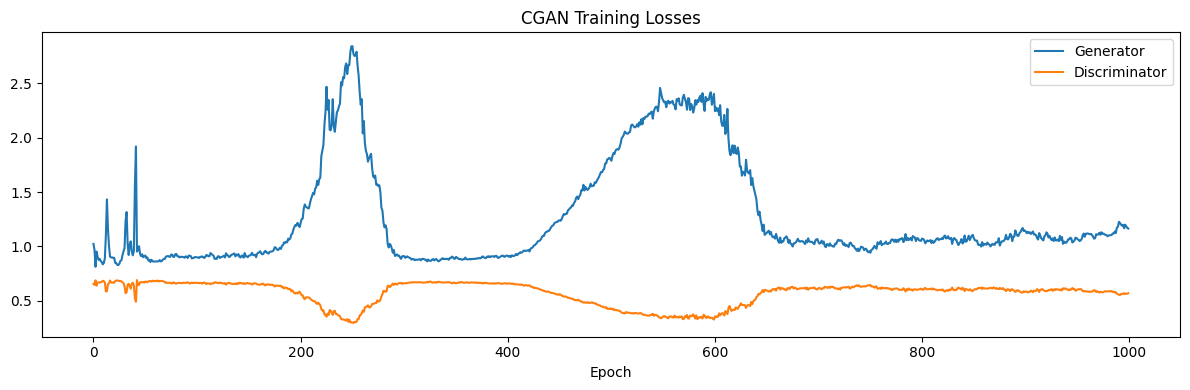

Final G loss: 1.1646
Final D loss: 0.5691
Healthy training: D loss should be ~0.5-0.7, G loss ~0.5-2.0


In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history_g, label="Generator")
ax.plot(history_d, label="Discriminator")
ax.set_title("CGAN Training Losses")
ax.set_xlabel("Epoch")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/cgan_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Final G loss: {history_g[-1]:.4f}")
print(f"Final D loss: {history_d[-1]:.4f}")
print("Healthy training: D loss should be ~0.5-0.7, G loss ~0.5-2.0")

In [22]:
torch.save(G.state_dict(), MODELS_DIR / "generator.pt")
torch.save(D.state_dict(), MODELS_DIR / "discriminator.pt")
print(f"Checkpoints saved -> {MODELS_DIR.resolve()}")

Checkpoints saved -> /content/data/processed/FD001/checkpoints_cgan


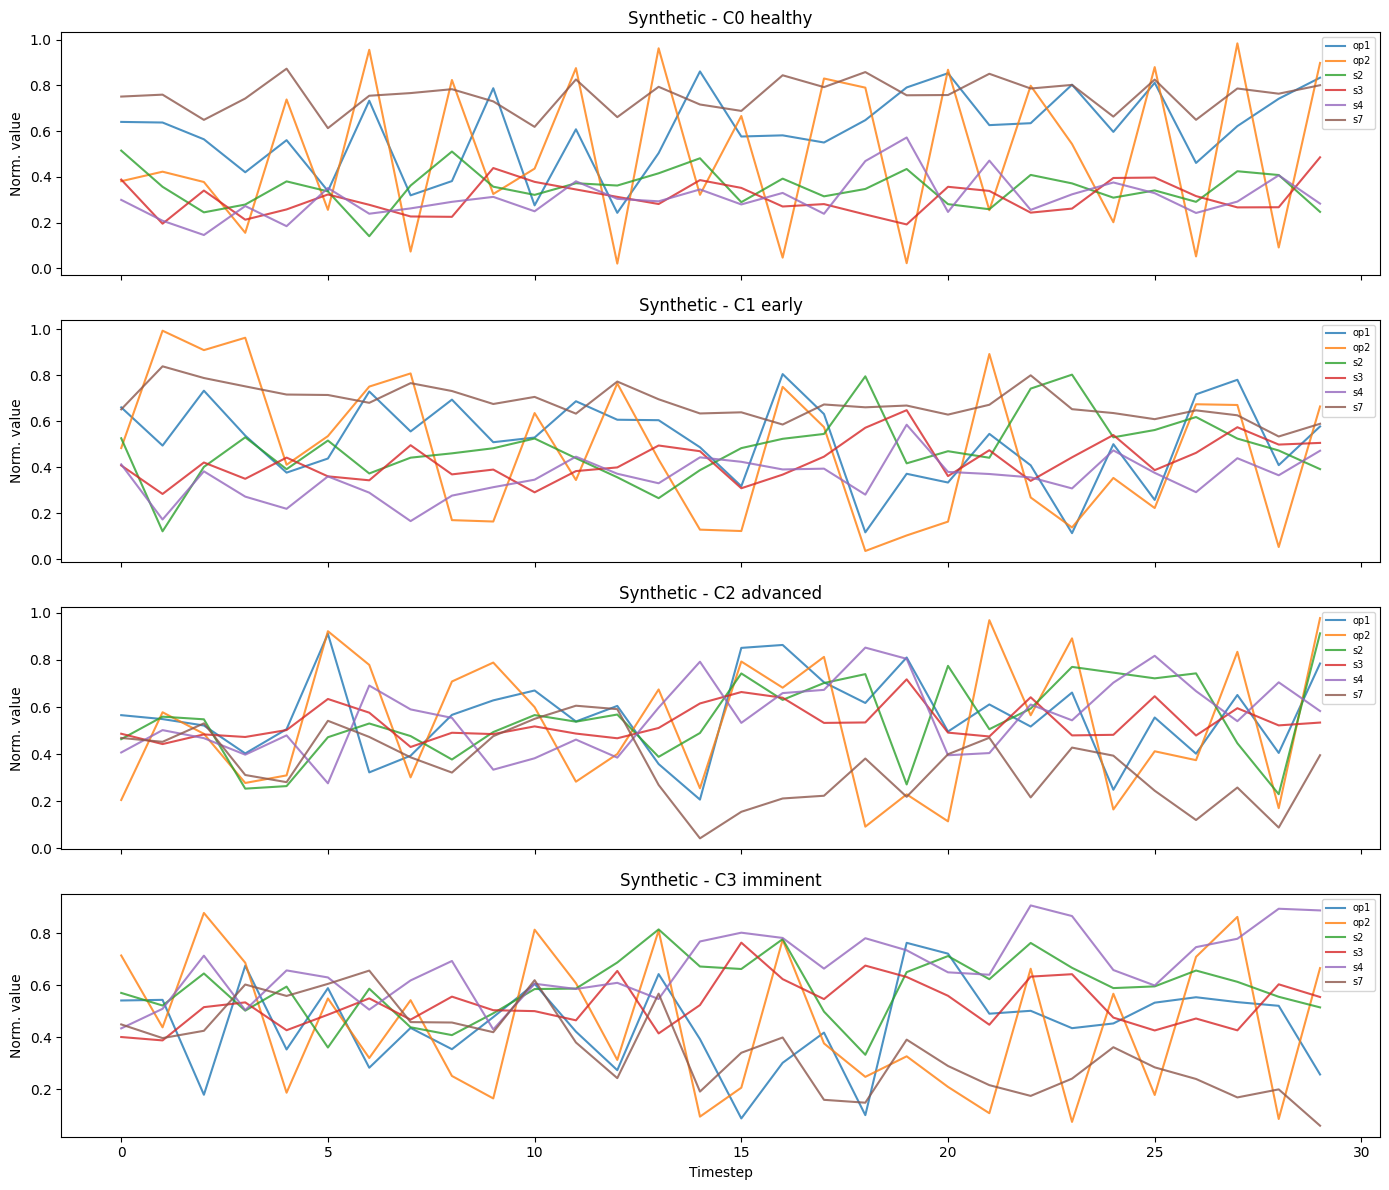

In [23]:
CLASS_NAMES  = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]
FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]   # 16 features — op3 removed

G.eval()
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

with torch.no_grad():
    for c in range(4):
        z        = torch.randn(1, LATENT_DIM).to(DEVICE)
        c_tensor = torch.tensor([c]).to(DEVICE)
        x_hat    = G(z, c_tensor).cpu().numpy()[0]   # (30, 16)

        ax = axes[c]
        for i, col in enumerate(FEATURE_COLS[:6]):
            ax.plot(x_hat[:, i], label=col, alpha=0.8)
        ax.set_title(f"Synthetic - {CLASS_NAMES[c]}")
        ax.set_ylabel("Norm. value")
        ax.legend(loc="upper right", fontsize=7)

axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.savefig("reports/figures/cgan_synthetic_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## Bundle & download results
Zips the trained checkpoints and generated figures with `shutil` so they can be downloaded from Colab in one go.


In [24]:
import shutil

# save final checkpoints
torch.save(G.state_dict(), MODELS_DIR / "generator.pt")
torch.save(D.state_dict(), MODELS_DIR / "discriminator.pt")

# if early stopping saved a best checkpoint, copy it as the primary
best_g = MODELS_DIR / "generator_best.pt"
best_d = MODELS_DIR / "discriminator_best.pt"
if best_g.exists():
    shutil.copy(best_g, MODELS_DIR / "generator.pt")
    shutil.copy(best_d, MODELS_DIR / "discriminator.pt")
    print("Using best checkpoint (saved by EarlyStopping).")
else:
    print("Using final checkpoint (EarlyStopping did not trigger).")

print(f"Checkpoints saved -> {MODELS_DIR.resolve()}")

Using best checkpoint (saved by EarlyStopping).
Checkpoints saved -> /content/data/processed/FD001/checkpoints_cgan
